In [256]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nba_api.stats.endpoints.drafthistory import DraftHistory
import requests

In [257]:
def get_draft_data(year):
    """Fetch WNBA draft data for a given year using the nba_api."""
    draft_data = DraftHistory(season_year_nullable=year, league_id='10')
    draft_df = draft_data.get_data_frames()[0]
    return draft_df

In [258]:
def get_team_stats(compid):
    team_stats_url = f'https://api.cbbanalytics.com/api/gs/team-agg-stats/competition/{compid}/division/1/scope/season/'
    team_stats_df = pd.DataFrame(requests.get(team_stats_url).json())
    team_stats_df['fullName'] = team_stats_df['teamMarket'] + ' ' + team_stats_df['teamName'] + ' ' + 'Women\'s'
    return team_stats_df

In [259]:
draft_2025_df = get_draft_data(2025)
draft_2025_df.head()

,PERSON_ID,PLAYER_NAME,SEASON,ROUND_NUMBER,ROUND_PICK,OVERALL_PICK,DRAFT_TYPE,TEAM_ID,TEAM_CITY,TEAM_NAME,TEAM_ABBREVIATION,ORGANIZATION,ORGANIZATION_TYPE,PLAYER_PROFILE_FLAG
0,1642784,Paige Bueckers,2025,1,1,1,Draft,1611661321,Dallas,Wings,DAL,,,1
1,1642798,Dominique Malonga,2025,1,2,2,Draft,1611661328,Seattle,Storm,SEA,,,1
2,1642785,Sonia Citron,2025,1,3,3,Draft,1611661322,Washington,Mystics,WAS,,,1
3,1642792,Kiki Iriafen,2025,1,4,4,Draft,1611661322,Washington,Mystics,WAS,,,1
4,1642794,Juste Jocyte,2025,1,5,5,Draft,1611661331,Golden State,Valkyries,GSV,,,1


In [260]:
drafted_players_2025 = draft_2025_df['PLAYER_NAME'].unique()

In [261]:
player_stats_2025 = pd.read_csv('./data/Copy of WBB Data - ncaa_2425.csv')
player_stats_2025 = player_stats_2025[player_stats_2025['Class'] == 'SR']
player_stats_2025['Drafted'] = player_stats_2025['Player'].apply(lambda x: 1 if x in drafted_players_2025 else 0)

In [262]:
player_stats_2025.head()

,Team,Player,#,Class,Height,Summary,G,GS,MP,FG,...,OWS,DWS,WS,WS/40,OBPM,DBPM,BPM,Conference,Season,Drafted
0,Youngstown State Penguins Women's,Jewel Watkins,10,SR,5-11,"15.3 Pts, 3.4 Reb, 1.5 Ast",31.0,31.0,1006.0,160.0,...,1.2,1.2,2.4,0.097,-1.0,-1.9,-2.9,Horizon WBB,2024-2025,0
1,Youngstown State Penguins Women's,Malia Magestro,2,SR,5-9,"11.1 Pts, 2.5 Reb, 2.3 Ast",27.0,26.0,870.0,93.0,...,1.4,0.8,2.2,0.102,-1.3,-1.7,-3.0,Horizon WBB,2024-2025,0
3,Youngstown State Penguins Women's,Faith Burch,22,SR,6-1,"6.8 Pts, 5.8 Reb, 0.8 Ast",26.0,22.0,550.0,68.0,...,-0.1,0.9,0.8,0.058,-4.5,-1.4,-5.9,Horizon WBB,2024-2025,0
5,Youngstown State Penguins Women's,Haley Thierry,23,SR,5-8,"4.9 Pts, 5.1 Reb, 1.7 Ast",29.0,6.0,591.0,48.0,...,0.9,1.1,2.0,0.138,-0.8,1.0,0.1,Horizon WBB,2024-2025,0
15,Yale Bulldogs Women's,Mackenzie Egger,24,SR,5-11,"15.3 Pts, 9.4 Reb, 1.5 Ast",26.0,26.0,891.0,156.0,...,1.3,0.8,2.1,0.093,1.9,-1.0,0.8,Ivy WBB,2024-2025,0


In [263]:
team_stats_df_2025 = get_team_stats(38529)

In [264]:
from difflib import get_close_matches

api_names = team_stats_df_2025['fullName'].tolist()

def best_match(name, api_names=api_names):
    if name in api_names:                                      # exact first
        return name
    m = get_close_matches(name, api_names, n=1, cutoff=0.6)   # fuzzy fallback
    return m[0] if m else None

team_map = {t: best_match(t) for t in player_stats_2025['Team'].unique()}
player_stats_2025['_team_key'] = player_stats_2025['Team'].map(team_map)

unmatched = [t for t, v in team_map.items() if v is None]
print(f"Matched: {player_stats_2025['_team_key'].notna().sum():,} / {len(player_stats_2025):,} rows")
print(f"Unmatched teams ({len(unmatched)}): {unmatched[:10]}")


Matched: 1,758 / 1,758 rows
Unmatched teams (0): []


In [265]:
team_rating_cols = ['fullName','sos','netRanking','netRtgAdjGap','netRtgAdj','ortgAdjGap','ortgAdj','drtgAdjGap','drtgAdj']

# isOffense==True gives one row per team (vs the defensive split row) — use it just for dedup
team_stats_dedup = (team_stats_df_2025[team_stats_df_2025['isOffense'] == True][team_rating_cols]
                    .drop_duplicates(subset='fullName'))

player_stats_2025 = pd.merge(
    player_stats_2025,
    team_stats_dedup,
    left_on='_team_key',
    right_on='fullName',
    how='left'
).drop(columns=['_team_key', 'fullName'])

print(f"Rows: {len(player_stats_2025)}")
print(f"Team ratings filled: {player_stats_2025['netRtgAdj'].notna().sum():,} rows")
player_stats_2025[['Team','netRtgAdj','ortgAdj','drtgAdj','sos']].dropna().head()


Rows: 1758
Team ratings filled: 1,758 rows


,Team,netRtgAdj,ortgAdj,drtgAdj,sos
0,Youngstown State Penguins Women's,-14.5647,81.2871,95.8517,0.46289
1,Youngstown State Penguins Women's,-14.5647,81.2871,95.8517,0.46289
2,Youngstown State Penguins Women's,-14.5647,81.2871,95.8517,0.46289
3,Youngstown State Penguins Women's,-14.5647,81.2871,95.8517,0.46289
4,Yale Bulldogs Women's,-24.7517,79.8615,104.6132,0.51024


In [266]:
def feature_engineering(dframe):
    df = dframe.copy()
    # ── 1. Physical / Identity ────────────────────────────────────────────────────
    def height_to_inches(h):
        try:
            ft, inch = str(h).split('-')
            return int(ft) * 12 + int(inch)
        except Exception:
            return np.nan

    df['height_in'] = df['Height'].apply(height_to_inches)

    class_map = {'FR': 1, 'So': 2, 'SO': 2, 'JR': 3, 'Jr': 3, 'SR': 4, 'Sr': 4, 'GR': 5, 'Gr': 5}
    df['class_ord'] = df['Class'].map(class_map).fillna(2)

    # ── 2. Per-game rates ─────────────────────────────────────────────────────────
    per_game_cols = {'PTS': 'pts_pg', 'TRB': 'trb_pg', 'AST': 'ast_pg',
                    'STL': 'stl_pg', 'BLK': 'blk_pg', 'TOV': 'tov_pg',
                    'FGA': 'fga_pg', 'FTA': 'fta_pg', 'MP':  'mp_pg'}
    for raw, feat in per_game_cols.items():
        df[feat] = df[raw] / df['G'].replace(0, np.nan)

    # ── 3. Per-40-minute rates (controls for PT differences) ─────────────────────
    mp_safe = df['MP'].replace(0, np.nan)
    per40_cols = {'PTS': 'pts_p40', 'TRB': 'trb_p40', 'AST': 'ast_p40',
                'STL': 'stl_p40', 'BLK': 'blk_p40', 'TOV': 'tov_p40',
                'ORB': 'orb_p40', 'DRB': 'drb_p40'}
    for raw, feat in per40_cols.items():
        df[feat] = df[raw] / mp_safe * 40

    # ── 4. Efficiency / ratio features ───────────────────────────────────────────
    df['ast_tov_ratio']     = df['AST'] / df['TOV'].replace(0, np.nan)
    df['stl_blk_pg']        = df['stl_pg'] + df['blk_pg']          # defensive disruption
    df['stl_blk_tov_ratio'] = df['stl_blk_pg'] / df['tov_pg'].replace(0, np.nan)
    df['pts_per_fga']       = df['PTS'] / df['FGA'].replace(0, np.nan)  # raw scoring efficiency
    df['ft_rate']           = df['FTA'] / df['FGA'].replace(0, np.nan)  # drawing contact
    df['non3_fg_pct']       = df['2P'] / df['2PA'].replace(0, np.nan)   # interior efficiency
    df['rim_rate']          = df['2PA'] / df['FGA'].replace(0, np.nan)  # shot profile (inside vs perimeter)
    df['games_started_pct'] = df['GS'] / df['G'].replace(0, np.nan)     # starter vs bench role

    # ── 5. Composite impact scores ────────────────────────────────────────────────
    # Offensive impact: PER + OBPM, scaled by usage
    df['off_composite']  = df['PER'] + df['OBPM'] + df['USG%'] / 10
    # Defensive impact: DBPM + steal/block rates
    df['def_composite']  = df['DBPM'] + df['STL%'] + df['BLK%']
    # Two-way BPM gap (positive = better offensively, negative = defensive specialist)
    df['bpm_gap']        = df['OBPM'] - df['DBPM']
    # Win-share efficiency (quality of contribution relative to minutes)
    df['ws_per_game']    = df['WS'] / df['G'].replace(0, np.nan)
    # Versatility: scoring + rebounding + playmaking per 40
    df['versatility']    = df['pts_p40'] + df['trb_p40'] + df['ast_p40']
    # Pure scoring load: how much of team usage they handle vs how efficiently
    df['scoring_load']   = df['USG%'] * df['TS%']
    # Production composite (mimics scouts' box-score checklist)
    df['prod_composite'] = (
        df['pts_pg'] * 1.0 +
        df['trb_pg'] * 1.2 +
        df['ast_pg'] * 1.5 +
        df['stl_pg'] * 2.0 +
        df['blk_pg'] * 2.0 -
        df['tov_pg'] * 1.5
    )

    # ── 6. Conference strength tier ───────────────────────────────────────────────
    power_conf  = {'ACC WBB', 'Big Ten WBB', 'SEC WBB', 'Big 12 WBB', 'Pac-12 WBB'}
    high_conf   = {'Big East WBB', 'American Athletic WBB', 'Mountain West WBB', 'Atlantic 10 WBB'}
    mid_conf    = {'Missouri Valley WBB', 'WAC WBB', 'Sun Belt WBB', 'Conference USA WBB', 'WCC WBB'}

    def conf_tier(c):
        if c in power_conf: return 3
        if c in high_conf:  return 2
        if c in mid_conf:   return 1
        return 0

    df['conf_tier'] = df['Conference'].apply(conf_tier)
    # Conference-adjusted BPM: reward good BPM in stronger conferences
    df['bpm_sos_adj'] = df['BPM'] * (1 + df['sos'])

    # ── 7. Percentile ranks (within full player pool) ────────────────────────────
    pct_cols = ['BPM', 'WS', 'WS/40', 'PER', 'TS%', 'prod_composite',
                'versatility', 'off_composite', 'def_composite', 'bpm_sos_adj']
    for col in pct_cols:
        df[f'{col}_pct'] = df[col].rank(pct=True)
    return df

In [267]:
df = feature_engineering(player_stats_2025)

# ── Summary ───────────────────────────────────────────────────────────────────
new_feats = [c for c in df.columns if c not in player_stats_2025.columns]
print(f"Engineered {len(new_feats)} new features:")
print(new_feats)
df[new_feats + ['Drafted']].describe()


Engineered 46 new features:
['height_in', 'class_ord', 'pts_pg', 'trb_pg', 'ast_pg', 'stl_pg', 'blk_pg', 'tov_pg', 'fga_pg', 'fta_pg', 'mp_pg', 'pts_p40', 'trb_p40', 'ast_p40', 'stl_p40', 'blk_p40', 'tov_p40', 'orb_p40', 'drb_p40', 'ast_tov_ratio', 'stl_blk_pg', 'stl_blk_tov_ratio', 'pts_per_fga', 'ft_rate', 'non3_fg_pct', 'rim_rate', 'games_started_pct', 'off_composite', 'def_composite', 'bpm_gap', 'ws_per_game', 'versatility', 'scoring_load', 'prod_composite', 'conf_tier', 'bpm_sos_adj', 'BPM_pct', 'WS_pct', 'WS/40_pct', 'PER_pct', 'TS%_pct', 'prod_composite_pct', 'versatility_pct', 'off_composite_pct', 'def_composite_pct', 'bpm_sos_adj_pct']


,height_in,class_ord,pts_pg,trb_pg,ast_pg,stl_pg,blk_pg,tov_pg,fga_pg,fta_pg,...,WS_pct,WS/40_pct,PER_pct,TS%_pct,prod_composite_pct,versatility_pct,off_composite_pct,def_composite_pct,bpm_sos_adj_pct,Drafted
count,1757.000000,1758.0,1571.000000,1571.000000,1571.000000,1571.000000,1571.000000,1571.000000,1571.000000,1571.000000,...,1571.000000,1570.000000,1570.000000,1563.000000,1571.000000,1570.000000,1568.000000,1568.000000,1568.000000,1758.000000
mean,70.656801,4.0,7.279117,3.572404,1.507030,0.882286,0.353452,1.606206,6.397336,1.795530,...,0.500318,0.500318,0.500318,0.500320,0.500318,0.500318,0.500319,0.500319,0.500319,0.018771
std,3.205033,0.0,4.701390,2.205265,1.209687,0.601059,0.430933,0.883765,3.827513,1.384490,...,0.288669,0.288764,0.288763,0.288764,0.288767,0.288767,0.288767,0.288762,0.288767,0.135755
min,61.000000,4.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000637,0.000637,0.000637,0.003839,0.000955,0.003185,0.000638,0.000638,0.000638,0.000000
25%,68.000000,4.0,3.478261,1.965476,0.606061,0.444444,0.081667,0.953261,3.311422,0.700000,...,0.249204,0.250000,0.248726,0.250480,0.250477,0.250637,0.250478,0.253109,0.250478,0.000000
50%,71.000000,4.0,6.722222,3.200000,1.225806,0.794872,0.206897,1.533333,6.045455,1.518519,...,0.497772,0.499363,0.500955,0.500000,0.500318,0.500318,0.500319,0.499043,0.500319,0.000000
75%,73.000000,4.0,10.369318,4.766667,2.063508,1.208711,0.454545,2.176471,8.945195,2.559028,...,0.746022,0.750478,0.748089,0.751759,0.750159,0.750398,0.750159,0.747768,0.750159,0.000000
max,80.000000,4.0,24.375000,13.472222,7.277778,4.058824,3.657143,4.600000,18.576923,8.343750,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [268]:
df = df[(df['mp_pg'] >= df['mp_pg'].mean()) & (df['G'] >= df['G'].mean())]

In [269]:
corr = df.select_dtypes(include=[np.number]).corr()
corr_drafted = corr['Drafted'].reset_index()
corr_drafted['abs'] = corr_drafted['Drafted'].abs()
corr_drafted.sort_values('abs', ascending=False)[['index', 'Drafted','abs']].head(20)

,index,Drafted,abs
46,Drafted,1.000000,1.000000
90,bpm_sos_adj,0.414999,0.414999
45,BPM,0.402560,0.402560
43,OBPM,0.367022,0.367022
50,netRtgAdj,0.364713,0.364713
52,ortgAdj,0.351275,0.351275
44,DBPM,0.344464,0.344464
41,WS,0.343781,0.343781
49,netRtgAdjGap,0.337706,0.337706
47,sos,0.334727,0.334727


In [277]:
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_val_predict, RandomizedSearchCV, LeaveOneOut)
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from scipy.stats import randint, loguniform, uniform
import scipy.stats

# DRAFT_SLOTS = 36

drop_raw   = ['FG','FGA','FT','FTA','3P','3PA','2P','2PA','ORB','DRB','TRB',
              'AST','STL','BLK','TOV','PF','PTS','MP','PProd','#']

feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c != 'Drafted' and c not in drop_raw]

X = df[feature_cols]
y = df['Drafted']

imputer = SimpleImputer(strategy='median')
X_imp   = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols, index=X.index)

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y
)

neg, pos = (y_train == 0).sum(), y_train.sum()
spw = neg / pos
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"All features: {len(feature_cols)}")
print(f"Train — total: {len(y_train):,}  drafted: {pos}  not drafted: {neg}  imbalance: {neg/pos:.0f}:1")
print(f"Test  — total: {len(y_test):,}   drafted: {y_test.sum()}  not drafted: {(y_test==0).sum()}")

All features: 80
Train — total: 602  drafted: 23  not drafted: 579  imbalance: 25:1
Test  — total: 151   drafted: 6  not drafted: 145


In [278]:
# Helper function for model training and evaluation
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate_model(clf, X_train, y_train, X_test, y_test, name=None):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf, 'predict_proba') else y_pred
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    print(f"{name or clf.__class__.__name__}: ROC AUC = {roc_auc:.3f}, PR AUC = {pr_auc:.3f}")
    return {'name': name or clf.__class__.__name__, 'roc_auc': roc_auc, 'pr_auc': pr_auc}

In [279]:
# XGBoost Classifier
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_results = evaluate_model(xgb_clf, X_train, y_train, X_test, y_test, name='XGBoost')

XGBoost: ROC AUC = 0.972, PR AUC = 0.469


/Users/ryan/Library/Python/3.12/lib/python/site-packages/xgboost/training.py:200: UserWarning: [00:11:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [280]:
# LightGBM Classifier
lgbm_clf = LGBMClassifier(random_state=42)
lgbm_results = evaluate_model(lgbm_clf, X_train, y_train, X_test, y_test, name='LightGBM')

[LightGBM] [Info] Number of positive: 23, number of negative: 579
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000782 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12311
[LightGBM] [Info] Number of data points in the train set: 602, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038206 -> initscore=-3.225808
[LightGBM] [Info] Start training from score -3.225808
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [281]:
# Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=42)
rf_results = evaluate_model(rf_clf, X_train, y_train, X_test, y_test, name='Random Forest')

Random Forest: ROC AUC = 0.984, PR AUC = 0.569


,name,roc_auc,pr_auc
2,Random Forest,0.984483,0.569048
1,LightGBM,0.975862,0.488889
0,XGBoost,0.972414,0.469408


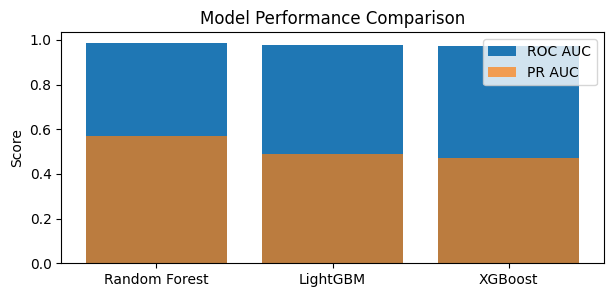

In [282]:
# Compare and summarize results
results = [xgb_results, lgbm_results, rf_results]
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('roc_auc', ascending=False)
display(results_df)

plt.figure(figsize=(7,3))
plt.bar(results_df['name'], results_df['roc_auc'], label='ROC AUC')
plt.bar(results_df['name'], results_df['pr_auc'], alpha=0.7, label='PR AUC')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()

In [285]:
# Full pipeline: fit on all data, predict draft probabilities for all players
# Choose best model (highest ROC AUC)
best_model_name = results_df.iloc[0]['name']
if best_model_name == 'XGBoost':
    best_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
elif best_model_name == 'LightGBM':
    best_clf = LGBMClassifier(random_state=42)
else:
    best_clf = RandomForestClassifier(random_state=42)

In [289]:
player_stats_2026 = pd.read_csv('./data/Copy of WBB Data - ncaa2526.csv')
player_stats_2026 = player_stats_2026[player_stats_2026['Class'] == 'SR']


In [290]:
player_stats_2026.head()

,Team,Player,#,Class,Pos,Height,Summary,G,GS,MP,...,USG%,OWS,DWS,WS,WS/40,OBPM,DBPM,BPM,Conference,Season
0,Youngstown State Penguins Women's,Casey Santoro,14.0,SR,G,5-4,"11.8 Pts, 5.5 Reb, 3.4 Ast",35.0,35.0,1263.0,...,19.7,2.7,2.3,5.0,0.158,0.3,0.0,0.3,Horizon WBB,2025-2026
15,Yale Bulldogs Women's,Kiley Capstraw,21.0,SR,G,5-10,"8.7 Pts, 6.5 Reb, 3.9 Ast",25.0,25.0,879.0,...,19.3,0.0,0.8,0.8,0.036,-2.9,-0.7,-3.6,Ivy WBB,2025-2026
30,Xavier Musketeers Women's,Savannah White,2.0,SR,F,6-2,"7.0 Pts, 7.3 Reb, 2.4 Ast",29.0,29.0,874.0,...,16.5,0.6,1.3,1.9,0.085,-0.1,3.2,3.0,Big East WBB,2025-2026
37,Xavier Musketeers Women's,Mya Moore,44.0,SR,F,6-0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Big East WBB,2025-2026
40,Wyoming Cowgirls Women's,Malene Pedersen,12.0,SR,G,5-11,"17.2 Pts, 4.0 Reb, 2.1 Ast",29.0,29.0,964.0,...,28.8,3.1,0.7,3.8,0.158,5.2,-1.9,3.4,MWC WBB,2025-2026


In [291]:
team_stats_df_2026 = get_team_stats(41098)

In [292]:
api_names = team_stats_df_2026['fullName'].tolist()

team_map = {t: best_match(t) for t in player_stats_2026['Team'].unique()}
player_stats_2026['_team_key'] = player_stats_2026['Team'].map(team_map)

unmatched = [t for t, v in team_map.items() if v is None]
print(f"Matched: {player_stats_2026['_team_key'].notna().sum():,} / {len(player_stats_2026):,} rows")
print(f"Unmatched teams ({len(unmatched)}): {unmatched[:10]}")


Matched: 1,412 / 1,412 rows
Unmatched teams (0): []


In [293]:
team_rating_cols = ['fullName','sos','netRanking','netRtgAdjGap','netRtgAdj','ortgAdjGap','ortgAdj','drtgAdjGap','drtgAdj']

# isOffense==True gives one row per team (vs the defensive split row) — use it just for dedup
team_stats_dedup = (team_stats_df_2026[team_stats_df_2026['isOffense'] == True][team_rating_cols]
                    .drop_duplicates(subset='fullName'))

player_stats_2026 = pd.merge(
    player_stats_2026,
    team_stats_dedup,
    left_on='_team_key',
    right_on='fullName',
    how='left'
).drop(columns=['_team_key', 'fullName'])

print(f"Rows: {len(player_stats_2026)}")
print(f"Team ratings filled: {player_stats_2026['netRtgAdj'].notna().sum():,} rows")
player_stats_2026[['Team','netRtgAdj','ortgAdj','drtgAdj','sos']].dropna().head()


Rows: 1412
Team ratings filled: 1,407 rows


,Team,netRtgAdj,ortgAdj,drtgAdj,sos
0,Youngstown State Penguins Women's,5.5071,93.0572,87.5502,0.50579
1,Yale Bulldogs Women's,-14.0137,85.2906,99.3043,0.52132
2,Xavier Musketeers Women's,-9.8095,86.3185,96.1280,0.51785
3,Xavier Musketeers Women's,-9.8095,86.3185,96.1280,0.51785
4,Wyoming Cowgirls Women's,-11.2674,84.6573,95.9248,0.51651


In [296]:
df2 = feature_engineering(player_stats_2026)
# ── Summary ───────────────────────────────────────────────────────────────────
new_feats = [c for c in df2.columns if c not in player_stats_2026.columns]
print(f"Engineered {len(new_feats)} new features:")
print(new_feats)
df2[new_feats].describe()


Engineered 46 new features:
['height_in', 'class_ord', 'pts_pg', 'trb_pg', 'ast_pg', 'stl_pg', 'blk_pg', 'tov_pg', 'fga_pg', 'fta_pg', 'mp_pg', 'pts_p40', 'trb_p40', 'ast_p40', 'stl_p40', 'blk_p40', 'tov_p40', 'orb_p40', 'drb_p40', 'ast_tov_ratio', 'stl_blk_pg', 'stl_blk_tov_ratio', 'pts_per_fga', 'ft_rate', 'non3_fg_pct', 'rim_rate', 'games_started_pct', 'off_composite', 'def_composite', 'bpm_gap', 'ws_per_game', 'versatility', 'scoring_load', 'prod_composite', 'conf_tier', 'bpm_sos_adj', 'BPM_pct', 'WS_pct', 'WS/40_pct', 'PER_pct', 'TS%_pct', 'prod_composite_pct', 'versatility_pct', 'off_composite_pct', 'def_composite_pct', 'bpm_sos_adj_pct']


,height_in,class_ord,pts_pg,trb_pg,ast_pg,stl_pg,blk_pg,tov_pg,fga_pg,fta_pg,...,BPM_pct,WS_pct,WS/40_pct,PER_pct,TS%_pct,prod_composite_pct,versatility_pct,off_composite_pct,def_composite_pct,bpm_sos_adj_pct
count,1412.000000,1412.0,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,...,1331.000000,1334.000000,1332.000000,1332.000000,1326.000000,1334.000000,1332.000000,1331.000000,1331.000000,1328.000000
mean,70.489377,4.0,6.969954,3.448764,1.450759,0.892729,0.334202,1.591057,6.206532,1.781211,...,0.500376,0.500375,0.500375,0.500375,0.500377,0.500375,0.500375,0.500376,0.500376,0.500377
std,3.173781,0.0,4.539392,2.181400,1.194219,0.626061,0.378892,0.904564,3.690287,1.348443,...,0.288778,0.288666,0.288781,0.288779,0.288780,0.288783,0.288783,0.288783,0.288779,0.288784
min,60.000000,4.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000751,0.000750,0.000751,0.000751,0.005656,0.000750,0.003003,0.000751,0.000751,0.000753
25%,68.000000,4.0,3.208760,1.829762,0.560625,0.433333,0.080000,0.900000,3.171296,0.735294,...,0.253193,0.259745,0.250845,0.251689,0.251885,0.250562,0.250563,0.250563,0.249812,0.250565
50%,70.000000,4.0,6.454545,3.127016,1.172414,0.793103,0.200000,1.546921,5.968246,1.514719,...,0.503381,0.501124,0.502252,0.500751,0.502262,0.500375,0.500375,0.500376,0.497746,0.500377
75%,73.000000,4.0,10.076923,4.624654,2.000000,1.235294,0.451613,2.181818,8.900634,2.531250,...,0.749437,0.745502,0.753754,0.749625,0.749717,0.750187,0.750188,0.750188,0.749812,0.750188
max,80.000000,4.0,24.062500,14.060606,8.448276,3.810811,2.705882,5.030303,19.343750,6.911765,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [297]:
df2 = df2[(df2['mp_pg'] >= df2['mp_pg'].mean()) & (df2['G'] >= df2['G'].mean())]

In [305]:
best_clf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
preds_2026 = best_clf.predict_proba(df2[feature_cols])[:, 1]

In [309]:
df2['Draft_Prob'] = preds_2026
df2['Pred_Drafted'] = (df2['Draft_Prob'] >= 0.5).astype(int)
df2[['Player', 'Team', 'Draft_Prob','Pred_Drafted']].sort_values('Draft_Prob', ascending=False).head(30)

,Player,Team,Draft_Prob,Pred_Drafted
363,Madina Okot,South Carolina Gamecocks Women's,0.74,1
727,Cotie McMahon,Ole Miss Rebels Women's,0.73,1
1200,Azzi Fudd,UConn Huskies Women's,0.70,1
364,Ta'Niya Latson,South Carolina Gamecocks Women's,0.66,1
365,Raven Johnson,South Carolina Gamecocks Women's,0.66,1
249,Rori Harmon,Texas Longhorns Women's,0.65,1
854,Flau'jae Johnson,LSU Lady Tigers Women's,0.64,1
896,Tonie Morgan,Kentucky Wildcats Women's,0.63,1
158,Gabriela Jaquez,UCLA Bruins Women's,0.63,1
159,Gianna Kneepkens,UCLA Bruins Women's,0.63,1
